# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

In [2]:
data_raw = pd.read_csv('data/cash_app_report_1782136207099.csv')
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-06-22 09:33:29 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,TGT,$133.40,0.07496,COMPLETE,$10 Purchase of Target,NaN,Cash Balance
1,2026-06-22 09:33:17 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,WFC,$82.92,0.12059,COMPLETE,$10 Sale of Wells Fargo,NaN,Cash Balance
2,2026-06-22 09:33:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.28,0.13462,COMPLETE,$10 Sale of Block,NaN,Cash Balance
3,2026-06-22 09:31:02 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,PD,$8.43,1.18632,COMPLETE,$10 Purchase of PagerDuty,NaN,Cash Balance
4,2026-06-22 09:30:58 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,SNAP,$4.57,2.18818,COMPLETE,$10 Purchase of Snap,NaN,Cash Balance
5,2026-06-22 09:30:49 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,AMD,$545.43,0.01833,COMPLETE,$10 Purchase of Advanced Micro Devices,NaN,Cash Balance
6,2026-06-22 09:30:48 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,MRVL,$313.48,0.03189,COMPLETE,$10 Sale of Marvell Technology,NaN,Cash Balance
7,2026-06-22 09:30:44 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HOOD,$108.10,0.09250,COMPLETE,$10 Sale of Robinhood Markets,NaN,Cash Balance
8,2026-06-22 09:30:40 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HIMS,$34.63,0.28876,COMPLETE,$10 Sale of Hims & Hers Health,NaN,Cash Balance
9,2026-06-22 09:30:24 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,DOCU,$42.29,0.11823,COMPLETE,$5 Purchase of DocuSign,NaN,Cash Balance


In [3]:
data_raw[data_raw['Transaction Type'].isna()]

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
1,2026-06-22 09:33:17 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,WFC,$82.92,0.12059,COMPLETE,$10 Sale of Wells Fargo,NaN,Cash Balance
2,2026-06-22 09:33:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.28,0.13462,COMPLETE,$10 Sale of Block,NaN,Cash Balance
6,2026-06-22 09:30:48 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,MRVL,$313.48,0.03189,COMPLETE,$10 Sale of Marvell Technology,NaN,Cash Balance
7,2026-06-22 09:30:44 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HOOD,$108.10,0.09250,COMPLETE,$10 Sale of Robinhood Markets,NaN,Cash Balance
8,2026-06-22 09:30:40 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HIMS,$34.63,0.28876,COMPLETE,$10 Sale of Hims & Hers Health,NaN,Cash Balance
11,2026-06-22 09:30:20 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,DKS,$237.13,0.04217,COMPLETE,$10 Sale of Dick's Sporting Goods,NaN,Cash Balance
12,2026-06-22 09:30:19 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,DAL,$84.50,0.11834,COMPLETE,$10 Sale of Delta Air Lines,NaN,Cash Balance
16,2026-06-22 09:30:15 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,JPM,$329.00,0.03039,COMPLETE,$10 Sale of JPMorgan Chase,NaN,Cash Balance
22,2026-06-22 09:30:04 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,AMAT,$626.22,0.00798,COMPLETE,$5 Sale of Applied Materials,NaN,Cash Balance
24,2026-06-22 09:30:03 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,PZZA,$35.71,0.28003,COMPLETE,$10 Sale of Papa John's,NaN,Cash Balance


In [4]:
data_raw['Asset Amount'].fillna(None).astype(float)

0      0.07496
1      0.12059
2      0.13462
3      1.18632
4      2.18818
        ...   
569        NaN
570        NaN
571        NaN
572        NaN
573        NaN
Name: Asset Amount, Length: 574, dtype: float64

In [5]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
525,2026-05-28 13:31:36+00:00,-10.0,-10.0,424.08,0.023580,0.0,TSM,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Taiwan Semiconductor Manufactu...,NaN
524,2026-05-28 19:43:12+00:00,-10.0,-9.8,73878.86,0.000133,-0.2,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00013265,NaN
495,2026-05-30 03:45:07+00:00,-50.0,-50.0,NaN,0.000000,0.0,NaN,Savings Internal Transfer,USD,NaN,Cash Balance,COMPLETE,Savings,NaN
485,2026-05-30 12:15:16+00:00,0.0,0.0,NaN,0.000000,NaN,NaN,Account Notifications,USD,NaN,Cash Balance,COMPLETE,New device login,NaN
451,2026-06-01 13:30:15+00:00,-10.0,-10.0,104.12,0.096040,0.0,VONV,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Vanguard Russell 1000 Value ETF,NaN
409,2026-06-02 16:50:38+00:00,-10.0,-10.0,34.52,0.289690,0.0,DOW,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Dow,NaN
328,2026-06-03 13:30:19+00:00,-1.0,-1.0,59.50,0.016800,0.0,OXY,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Occidental Petroleum,NaN
305,2026-06-03 15:07:22+00:00,-10.0,-10.0,7.54,1.326430,0.0,IEP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Icahn Enterprises,NaN
299,2026-06-03 15:11:16+00:00,-10.0,-10.0,116.23,0.086030,0.0,WMT,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Walmart,NaN
32,2026-06-18 17:17:47+00:00,-10.0,-10.0,186.78,0.053530,0.0,ORCL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Oracle,NaN


In [6]:
p2p_data = (data[data['trans_type'] == 'P2P']
 [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
    .assign(date=lambda x: x['date'].dt.date)
)
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
567,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
568,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
569,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
571,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
572,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
573,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


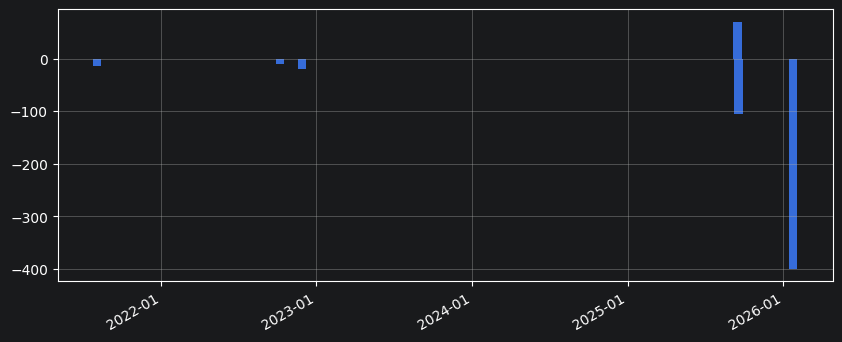

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [8]:
data.describe()

,net_amount,amount,asset_price,asset_amount,fee
count,574.000000,574.000000,482.000000,574.000000,571.000000
mean,0.200017,0.210366,4137.890975,0.132509,-0.010403
std,40.296951,40.294517,16285.437659,0.256123,0.056336
min,-400.000000,-400.000000,4.570000,0.000000,-0.500000
25%,-10.000000,-10.000000,56.900000,0.013272,0.000000
50%,-10.000000,-10.000000,131.800000,0.046700,0.000000
75%,-5.000000,-5.000000,300.640000,0.127965,0.000000
max,200.000000,200.000000,80346.140000,2.378910,0.000000


In [9]:
data.nunique().sort_values(ascending=False)

asset_price     476
asset_amount    474
date            456
notes           334
asset_type      164
amount           42
net_amount       41
trans_type       10
trans_id          7
fee               6
account           5
name_trans        5
status            2
currency          1
dtype: int64

In [10]:
data['asset_type'].value_counts()

asset_type
BTC     27
XYZ     12
JPM     12
WFC     10
ORCL    10
        ..
ADBE     1
JEPI     1
CBRS     1
AVGO     1
NVDA     1
Name: count, Length: 164, dtype: int64

Text(0, 0.5, 'Count')

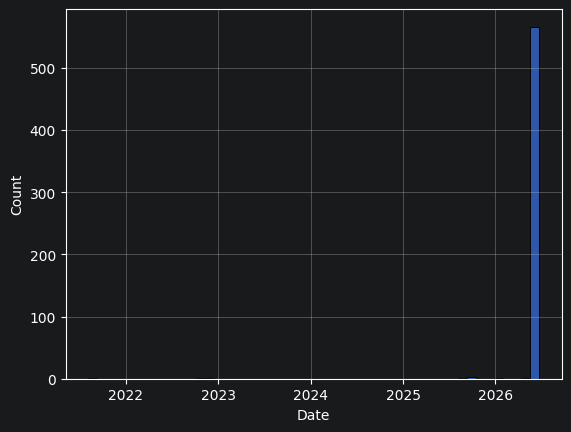

In [11]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [12]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2025-12-22,2026-05-27,2026-05-29,2026-06-01,2026-06-03,2026-06-15,2026-06-18,2026-06-20,2026-06-22


In [13]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,27,-172.26,"(-24.5, -9.8, -4.9, -0.98, 5.0, 10.0, 20.0)",7
XYZ,12,-161.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
JPM,12,-70.00,"(-25.0, -10.0, -5.0, 10.0, 20.0)",5
WFC,10,-71.00,"(-25.0, -10.0, -5.0, -1.0, 10.0)",5
ORCL,10,-85.00,"(-10.0, -5.0)",2
META,9,-71.00,"(-10.0, -5.0, -1.0)",3
AMZN,9,-151.00,"(-50.0, -25.0, -10.0, -1.0)",4
V,9,-101.00,"(-25.0, -20.0, -10.0, -5.0, -1.0)",5
PZZA,9,-75.00,"(-25.0, -10.0, -5.0, 10.0)",4


In [14]:
data['currency'].value_counts()

currency
USD    574
Name: count, dtype: int64

In [15]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    424
Deposits                      63
Stock Sell                    31
Bitcoin Buy                   22
Savings Internal Transfer     12
Stock Dividends                7
P2P                            6
Bitcoin Sell                   5
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [16]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,
total,22,5,424,7,31,489
BTC,22,5,0,0,0,27
XYZ,0,0,11,0,1,12
JPM,0,0,10,0,2,12
ORCL,0,0,10,0,0,10
WFC,0,0,9,0,1,10
V,0,0,9,0,0,9
AMZN,0,0,9,0,0,9
PZZA,0,0,8,0,1,9


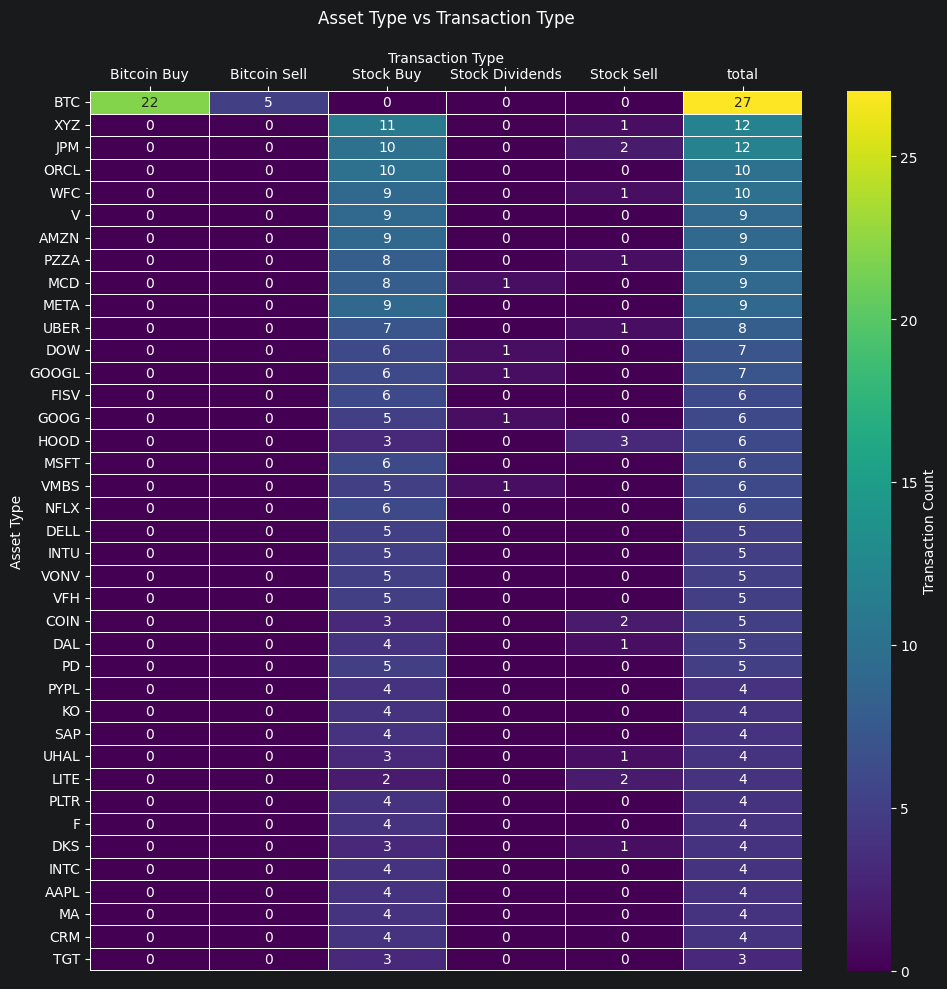

In [17]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [18]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
29,2026-06-20 20:54:15+00:00,9.8,10.00,63371.65,0.000158,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015780,NaN
31,2026-06-20 11:51:40+00:00,-5.0,-4.90,64191.63,0.000076,-0.10,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00007633,NaN
40,2026-06-18 17:13:37+00:00,19.6,20.00,61888.37,0.000323,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032316,NaN
122,2026-06-16 12:39:28+00:00,4.9,5.00,66069.72,0.000076,-0.10,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00007568,NaN
123,2026-06-16 12:03:53+00:00,4.9,5.00,65883.50,0.000076,-0.10,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00007589,NaN
126,2026-06-16 01:27:11+00:00,-5.0,-4.90,66797.17,0.000073,-0.10,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00007336,NaN
162,2026-06-08 16:36:43+00:00,19.6,20.00,63160.58,0.000317,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00031665,NaN
242,2026-06-03 19:29:17+00:00,-10.0,-9.80,66010.01,0.000148,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00014846,NaN
269,2026-06-03 16:16:50+00:00,-10.0,-9.80,66582.56,0.000147,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00014719,NaN
293,2026-06-03 15:14:44+00:00,-1.0,-0.98,66904.02,0.000015,-0.02,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00001465,NaN


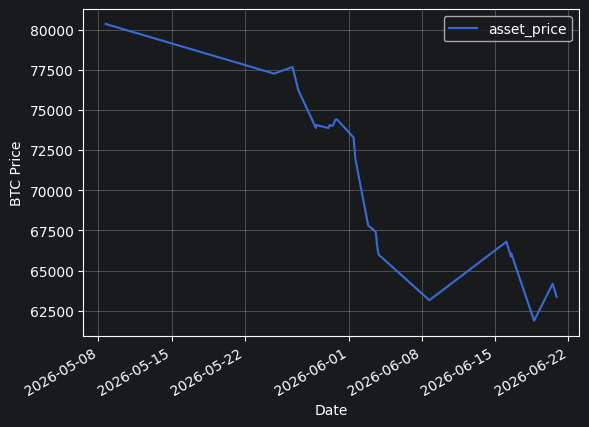

In [19]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [20]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     22
Bitcoin Sell     5
Name: count, dtype: int64

In [21]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-237.0
Bitcoin Sell,58.8


In [22]:
data_btc['net_amount'].sum()

np.float64(-178.2)

In [23]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003176
Bitcoin Sell    0.000949
Name: asset_amount, dtype: float64

In [24]:
data_btc['asset_amount'].sum()

np.float64(0.00412535)

In [25]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00222699)

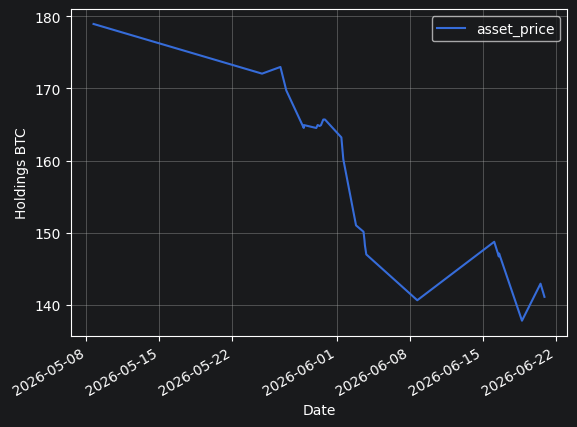

In [26]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [27]:
data_btc['asset_price'] * data_btc['asset_amount']

29     10.000046
31      4.899747
40     19.999846
122     5.000156
123     4.999899
126     4.900240
162    19.999798
242     9.799846
269     9.800287
293     0.980144
390     9.800221
401     0.979969
418     9.799652
476     4.900136
478     9.799865
481     4.900112
482     9.799903
486     9.799965
490    24.500200
497    24.499951
501    24.500084
520     9.799731
524     9.800031
547    24.499991
564     9.799898
565     4.900356
566     9.799819
dtype: float64

In [28]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
2,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
84,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
129,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
177,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
253,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
265,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
278,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
316,2026-06-03 13:43:52+00:00,-10.0,-10.0,71.59,0.13968,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
319,2026-06-03 13:33:56+00:00,-1.0,-1.0,72.82,0.01373,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Block,NaN
422,2026-06-01 13:30:51+00:00,-25.0,-25.0,77.50,0.32258,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$25 Purchase of Block,NaN


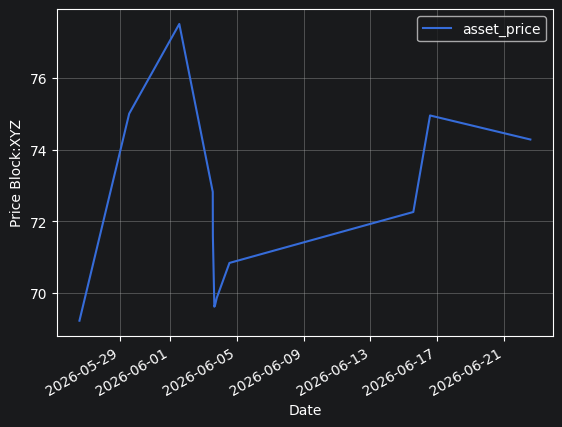

In [29]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [30]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     27
XYZ     12
JPM     12
WFC     10
ORCL    10
        ..
MU       1
MSGS     1
CAT      1
ABNB     1
ZG       1
Name: amount, Length: 164, dtype: int64

In [31]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,152.01,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,152.01,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,152.01,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,152.01,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,152.01,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [32]:
data['asset_amount'].describe()

count    574.000000
mean       0.132509
std        0.256123
min        0.000000
25%        0.013272
50%        0.046700
75%        0.127965
max        2.378910
Name: asset_amount, dtype: float64

In [33]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
)
asset_holding_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-27 13:33:02+00:00,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,21.666750,0.000000,0.000000,0.000000,0.000000
2026-06-03 15:06:50+00:00,20.147721,9.999493,9.010079,9.9981,10.098907,0.000000,19.549552,0.000000,14.039852,0.000000,...,19.705162,41.665912,9.686363,19.992722,9.999899,99.663815,0.000000,9.953370,0.000000,0.000000
2026-06-03 13:30:10+00:00,20.147721,9.999493,9.998704,9.9981,10.098907,0.000000,9.549584,0.000000,14.039852,0.000000,...,19.705162,30.766264,9.686363,19.992722,9.999899,93.073427,0.000000,9.953370,0.000000,0.000000
2026-06-16 13:30:22+00:00,28.691891,9.999493,11.181242,9.9981,19.320923,9.999577,19.549552,11.051107,14.039852,20.071824,...,19.705162,77.322328,18.724670,29.991989,9.999899,171.075624,30.191289,9.953370,9.999727,9.999925
2026-06-01 13:30:18+00:00,0.000000,0.000000,0.000000,9.9981,0.000000,0.000000,9.549584,0.000000,0.000000,0.000000,...,9.706497,4.945656,0.000000,9.555644,0.000000,74.055125,0.000000,0.000000,0.000000,0.000000
2026-06-18 17:09:36+00:00,28.691891,9.999493,16.180396,9.9981,19.320923,9.999577,19.549552,11.051107,14.039852,20.071824,...,19.705162,85.406771,23.724046,29.991989,9.999899,174.501547,30.191289,9.953370,9.999727,9.999925
2026-06-22 13:30:14+00:00,28.691891,9.999493,16.180396,9.9981,29.320654,9.999577,19.549552,21.050186,9.042617,20.071824,...,19.705162,85.406771,23.724046,29.991989,9.999899,174.501547,40.190894,19.954137,9.999727,9.999925
2026-06-18 14:12:37+00:00,28.691891,9.999493,16.180396,9.9981,19.320923,9.999577,19.549552,11.051107,14.039852,20.071824,...,19.705162,85.406771,23.724046,29.991989,9.999899,174.501547,30.191289,9.953370,9.999727,9.999925
2026-06-02 16:52:54+00:00,10.217560,0.000000,0.000000,9.9981,10.098907,0.000000,9.549584,0.000000,14.039852,0.000000,...,9.706497,30.766264,0.000000,19.992722,0.000000,93.073427,0.000000,0.000000,0.000000,0.000000


In [34]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(3975.1980214000005)

In [35]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-22 13:30:58+00:00,0.009733,0.002515,0.00407,0.002515,0.007376,0.002515,0.004918,0.005295,0.002275,0.007564,...,0.004957,0.021485,0.005968,0.007545,0.002516,0.043898,0.01011,0.00502,0.002516,0.002516
2026-06-22 13:31:02+00:00,0.009733,0.002515,0.00407,0.002515,0.007376,0.002515,0.004918,0.005295,0.002275,0.007564,...,0.004957,0.021485,0.005968,0.007545,0.002516,0.043898,0.01011,0.00502,0.002516,0.002516
2026-06-22 13:33:13+00:00,0.009733,0.002515,0.00407,0.002515,0.007376,0.002515,0.004918,0.005295,0.002275,0.007564,...,0.004957,0.021485,0.005968,0.007545,0.002516,0.041382,0.01011,0.00502,0.002516,0.002516
2026-06-22 13:33:17+00:00,0.009733,0.002515,0.00407,0.002515,0.007376,0.002515,0.004918,0.005295,0.002275,0.007564,...,0.004957,0.018969,0.005968,0.007545,0.002516,0.041382,0.01011,0.00502,0.002516,0.002516
2026-06-22 13:33:29+00:00,0.009733,0.002515,0.00407,0.002515,0.007376,0.002515,0.004918,0.005295,0.002275,0.007564,...,0.004957,0.018969,0.005968,0.007545,0.002516,0.041382,0.01011,0.00502,0.002516,0.002516


In [36]:
asset_price_rel.iloc[-1].describe()

count    164.000000
mean       0.006098
std        0.005955
min        0.000000
25%        0.002516
50%        0.004998
75%        0.007318
max        0.041382
Name: 2026-06-22 13:33:29+00:00, dtype: float64

In [37]:
asset_price_rel.iloc[-1].sort_values(ascending=False).head()

asset_type
XYZ     0.041382
AMZN    0.035832
V       0.026206
DELL    0.025858
UBER    0.024191
Name: 2026-06-22 13:33:29+00:00, dtype: float64

In [38]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-22 13:30:58+00:00,0.009733,0.002515,0.00407,0.002515,0.007376,0.002515,0.004918,0.005295,0.002275,0.007564,...,0.004957,0.021485,0.005968,0.007545,0.002516,0.043898,0.01011,0.00502,0.002516,0.002516
2026-06-22 13:31:02+00:00,0.009733,0.002515,0.00407,0.002515,0.007376,0.002515,0.004918,0.005295,0.002275,0.007564,...,0.004957,0.021485,0.005968,0.007545,0.002516,0.043898,0.01011,0.00502,0.002516,0.002516
2026-06-22 13:33:13+00:00,0.009733,0.002515,0.00407,0.002515,0.007376,0.002515,0.004918,0.005295,0.002275,0.007564,...,0.004957,0.021485,0.005968,0.007545,0.002516,0.041382,0.01011,0.00502,0.002516,0.002516
2026-06-22 13:33:17+00:00,0.009733,0.002515,0.00407,0.002515,0.007376,0.002515,0.004918,0.005295,0.002275,0.007564,...,0.004957,0.018969,0.005968,0.007545,0.002516,0.041382,0.01011,0.00502,0.002516,0.002516
2026-06-22 13:33:29+00:00,0.009733,0.002515,0.00407,0.002515,0.007376,0.002515,0.004918,0.005295,0.002275,0.007564,...,0.004957,0.018969,0.005968,0.007545,0.002516,0.041382,0.01011,0.00502,0.002516,0.002516


In [39]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-03 15:19:46+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:24:06+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 13:34:50+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 01:27:11+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-18 14:12:37+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-10 13:30:34+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-27 13:33:02+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-08 16:30:19+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:37:18+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,149.14,NaN,NaN,NaN


In [40]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-03 15:19:46+00:00,1.021803,1.0,1.000000,1.0,1.01,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.008655,1.000000,0.976969,1.0,1.034089,1.000000,1.0,1.0,1.0
2026-06-03 19:24:06+00:00,1.021803,1.0,1.000000,1.0,1.01,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.012014,0.968648,0.976969,1.0,1.009245,1.000000,1.0,1.0,1.0
2026-06-03 13:34:50+00:00,1.021803,1.0,1.000000,1.0,1.00,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.016277,1.000000,0.955619,1.0,1.051856,1.000000,1.0,1.0,1.0
2026-06-16 01:27:11+00:00,1.018386,1.0,1.000000,1.0,1.01,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.0,1.0,1.0
2026-06-18 14:12:37+00:00,1.018386,1.0,0.719207,1.0,1.01,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.082418,0.921293,0.976969,1.0,1.082623,0.997325,1.0,1.0,1.0
2026-06-10 13:30:34+00:00,1.018386,1.0,1.000000,1.0,1.01,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.035138,0.968648,0.976969,1.0,1.023256,0.997325,1.0,1.0,1.0
2026-05-27 13:33:02+00:00,1.000000,1.0,1.000000,1.0,1.00,1.0,1.000000,1.0,1.0,1.0,...,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.0
2026-06-08 16:30:19+00:00,1.021803,1.0,1.000000,1.0,1.01,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.035138,0.968648,0.976969,1.0,1.023256,0.997325,1.0,1.0,1.0
2026-06-03 19:37:18+00:00,1.021803,1.0,1.000000,1.0,1.01,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.016406,0.968648,0.976969,1.0,1.009245,0.997325,1.0,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

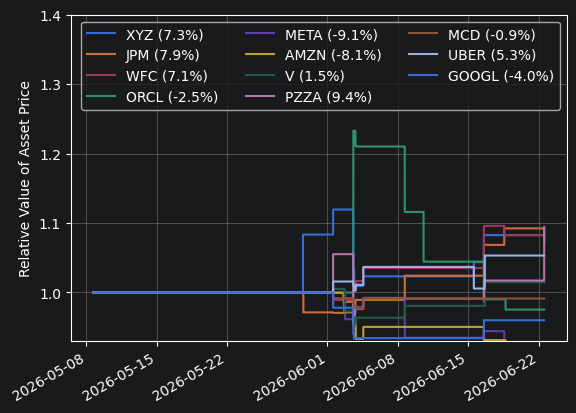

In [41]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
asset_price_rel_plot.plot.line()
plt.grid()
plt.legend(ncols=3, loc='upper right')
plt.ylim(0.93, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [42]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-06-22 13:30:58+00:00    1.082623
2026-06-22 13:31:02+00:00    1.082623
2026-06-22 13:33:13+00:00    1.072945
2026-06-22 13:33:17+00:00    1.072945
2026-06-22 13:33:29+00:00    1.072945
Name: XYZ, Length: 365, dtype: float64

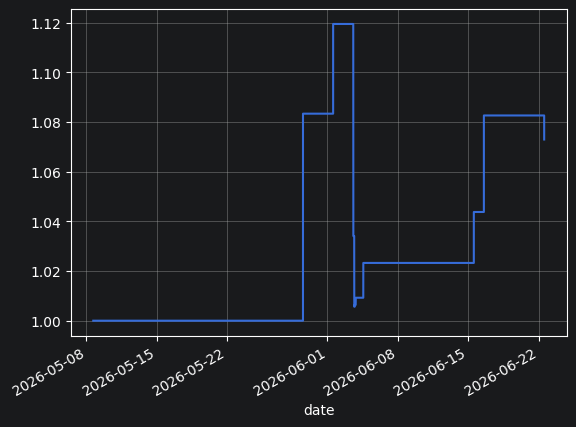

In [44]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [45]:
(data[data['trans_type'] == 'Stock Dividends']
 .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status', 'trans_type', 'net_amount'])
 )

,date,amount,asset_type,notes
48,2026-06-18 16:29:52+00:00,0.04,GM,$0.04 Dividend from General Motors
62,2026-06-18 04:00:00+00:00,0.07,HD,$0.07 Dividend from Home Depot
124,2026-06-16 04:00:00+00:00,0.20,MCD,$0.20 Dividend from McDonald's
142,2026-06-15 04:00:00+00:00,0.02,GOOG,$0.02 Dividend from Alphabet Inc. Class C
143,2026-06-15 04:00:00+00:00,0.02,GOOGL,$0.02 Dividend from Alphabet Inc. Class A
146,2026-06-12 04:00:00+00:00,0.05,DOW,$0.05 Dividend from Dow
399,2026-06-03 04:00:00+00:00,0.03,VMBS,$0.03 Dividend from Vanguard Mortgage-Backed S...


In [46]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
273,2026-06-03 15:53:29+00:00,-10.0,54.44,$10 Purchase of Vanguard Long-Treasury ETF,VGLT
361,2026-06-03 13:30:07+00:00,-10.0,125.39,$10 Purchase of Vanguard Financials ETF,VFH
114,2026-06-16 13:30:03+00:00,-5.0,155.47,$5 Purchase of Energy ETF Vanguard,VDE
98,2026-06-16 13:30:12+00:00,-5.0,107.50,$5 Purchase of Vanguard Russell 1000 Value ETF,VONV
27,2026-06-22 13:30:00+00:00,-5.0,238.55,$5 Purchase of Small Cap Value ETF Vanguard,VBR
342,2026-06-03 13:30:13+00:00,-10.0,48.13,$10 Purchase of Vanguard Total International B...,BNDX
458,2026-06-01 13:30:10+00:00,-10.0,397.97,$10 Purchase of Vanguard Consumer Discretionar...,VCR
17,2026-06-22 13:30:14+00:00,-10.0,131.87,$10 Purchase of Vanguard Financials ETF,VFH
61,2026-06-18 14:06:52+00:00,-5.0,50.45,$5 Purchase of Vanguard Tax-Exempt Bond ETF,VTEB
132,2026-06-15 13:30:28+00:00,-10.0,107.49,$10 Purchase of Vanguard Russell 1000 Value ETF,VONV


In [47]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VMBS    6
VFH     5
VONV    5
VNQ     3
VOO     3
VDE     3
VHT     3
VSS     3
VBR     2
VONG    2
VTEB    2
VGLT    2
VDC     2
BNDX    2
VCR     2
BIV     1
Name: count, dtype: int64

In [48]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
273,2026-06-03 15:53:29+00:00,-10.0,54.44,VGLT,Vanguard Long-Treasury ETF
361,2026-06-03 13:30:07+00:00,-10.0,125.39,VFH,Vanguard Financials ETF
114,2026-06-16 13:30:03+00:00,-5.0,155.47,VDE,Energy ETF Vanguard
98,2026-06-16 13:30:12+00:00,-5.0,107.50,VONV,Vanguard Russell 1000 Value ETF
27,2026-06-22 13:30:00+00:00,-5.0,238.55,VBR,Small Cap Value ETF Vanguard
342,2026-06-03 13:30:13+00:00,-10.0,48.13,BNDX,Vanguard Total International Bond ETF
458,2026-06-01 13:30:10+00:00,-10.0,397.97,VCR,Vanguard Consumer Discretionary ETF
17,2026-06-22 13:30:14+00:00,-10.0,131.87,VFH,Vanguard Financials ETF
61,2026-06-18 14:06:52+00:00,-5.0,50.45,VTEB,Vanguard Tax-Exempt Bond ETF
132,2026-06-15 13:30:28+00:00,-10.0,107.49,VONV,Vanguard Russell 1000 Value ETF


In [49]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VFH         Vanguard Financials ETF                        5
VMBS        Vanguard Mortgage-Backed Securities ETF        5
VONV        Vanguard Russell 1000 Value ETF                5
VDE         Energy ETF Vanguard                            3
VHT         Vanguard Health Care ETF                       3
VOO         Vanguard S&P 500 ETF                           3
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
BNDX        Vanguard Total International Bond ETF          2
VBR         Small Cap Value ETF Vanguard                   2
VCR         Vanguard Consumer Discretionary ETF            2
VDC         Vanguard Consumer Staples Index Fund ETF       2
VGLT        Vanguard Long-Treasury ETF                     2
VNQ         Vanguard Real Estate ETF                       2
VONG        Vanguard Russell 1000 Growth ETF               2
VTEB        Vanguard Tax-Exempt Bond ETF                   2
BIV         Vanguard Intermed

In [50]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VMBS,VFH,VONV,VNQ,VOO,VDE,VHT,VSS,VBR,VONG,VTEB,VGLT,VDC,BNDX,VCR,BIV
date,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN
2026-06-01 13:30:11+00:00,NaN,125.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:15+00:00,NaN,NaN,104.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:16+00:00,NaN,NaN,NaN,NaN,NaN,160.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:23+00:00,NaN,NaN,NaN,95.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
vanguard_trans_count

asset_type
VMBS    6
VFH     5
VONV    5
VNQ     3
VOO     3
VDE     3
VHT     3
VSS     3
VBR     2
VONG    2
VTEB    2
VGLT    2
VDC     2
BNDX    2
VCR     2
BIV     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

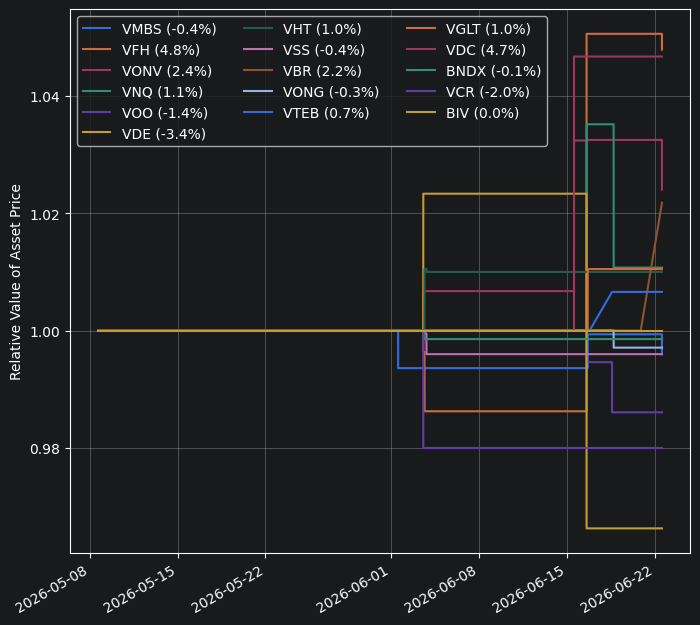

In [52]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')